# Tarea 3: Notebook de regresión

César Eduardo Jardines Mendoza Cuatrimestre III-2026 CICESE

## Descripción

**Calidad de vino tinto** (Cortez *et al.*, 2009). Usamos la copia del repositorio del curso.

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 42

# Cargamos el dataset
vinos = pd.read_csv("https://raw.githubusercontent.com/husseinlopez/icd2026/main/datos/winequality-red.csv")
print(f"{vinos.shape[0]} vinos × {vinos.shape[1]} columnas")
vinos["quality"].value_counts().sort_index()

1599 vinos × 12 columnas


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


In [19]:

print(f"{vinos.shape[0]} vinos × {vinos.shape[1]} columnas")
vinos.head()

1599 vinos × 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Los nombres de columna se conservan como vienen de la fuente. Las unidades son las que reporta el dataset original.

| Columna | Qué mide | Rango |
|---|---|---|
| `fixed acidity` | Acidez fija (g de ácido tartárico/dm³) | 4.6 a 15.9 |
| `volatile acidity` | Acidez volátil (g de ácido acético/dm³) | 0.12 a 1.58 |
| `citric acid` | Ácido cítrico (g/dm³) | 0 a 1 |
| `residual sugar` | Azúcar residual (g/dm³) | 0.9 a 15.5 |
| `chlorides` | Cloruros (g de cloruro de sodio/dm³) | 0.012 a 0.611 |
| `free sulfur dioxide` | Dióxido de azufre libre (mg/dm³) | 1 a 72 |
| `total sulfur dioxide` | Dióxido de azufre total (mg/dm³) | 6 a 289 |
| `density` | Densidad (g/cm³) | 0.990 a 1.004 |
| `pH` | pH | 2.74 a 4.01 |
| `sulphates` | Sulfatos (g de sulfato de potasio/dm³) | 0.33 a 2.00 |
| `alcohol` | Contenido de alcohol (% vol.) | 8.4 a 14.9 |
| `quality` | Calificación sensorial (variable objetivo) | 3 a 8 |

Los rangos de la tabla salen de la celda siguiente, que además confirma que no hay faltantes. Para corroborarlo vamos a obtener los valores de la tabla, los `min` y `max` y ver si hay faltantes.

In [3]:
resumen = vinos.agg(["min", "max"]).T
resumen["faltantes"] = vinos.isna().sum()
resumen.round(3)

,min,max,faltantes
fixed acidity,4.600,15.900,0
volatile acidity,0.120,1.580,0
citric acid,0.000,1.000,0
residual sugar,0.900,15.500,0
chlorides,0.012,0.611,0
free sulfur dioxide,1.000,72.000,0
total sulfur dioxide,6.000,289.000,0
density,0.990,1.004,0
pH,2.740,4.010,0
sulphates,0.330,2.000,0


Por lo que la distribución de la variable objetivo se puede ver de la siguiente manera.

In [5]:
vinos["quality"].value_counts().sort_index()

,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


### Variable objetivo

Antes de modelar conviene ver cómo se reparte `quality`, porque la tarea la usa de dos maneras. En la primera parte la tratamos como número. La regresión predice un valor continuo, aunque la calificación solo tome enteros. En la segunda la convertimos en clase con el corte `quality` ≥ 7, así que importa cuántos vinos quedan de cada lado. La celda siguiente cuenta cuántos vinos hay con cada calificación.

La calidad se concentra en dos valores:

- 681 vinos tienen 5
- 638 tienen 6

Y juntos el 82 % del conjunto. Observamos que los extremos son raros:
- 10 vinos con 3
- 18 con 8

Con el corte de la segunda parte, *bueno* = `quality` ≥ 7, solo 217 vinos (14 %) son buenos.

## Regresión: predecir la calidad

La primera pregunta que queremos responder es ¿cuánto?, es decir, qué calificación podría obtener un vino a partir de sus propiedades fisicoquímicas.

Para construir el modelo, separamos los datos en dos partes: utilizamos el 80 % de los vinos para entrenar el modelo y dejamos el 20 % restante para probar qué tan bien funciona. Esta división se hizo de la misma manera que en la sección 3 del notebook de clase.

Además, utilizamos `random_state` para fijar la forma en que se dividen los datos. De esta manera, cada vez que se ejecute el código se obtiene la misma partición y los resultados pueden compararse de forma consistente.

In [6]:
from sklearn.model_selection import train_test_split

X = vinos.drop(columns="quality")    # las once propiedades fisicoquímicas
y = vinos["quality"]                 # la calificación

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA)

print(f"Entrenamiento: {len(X_entrena)} vinos")
print(f"Prueba:         {len(X_prueba)} vinos")

Entrenamiento: 1279 vinos
Prueba:         320 vinos


Para tener un modelo simple con qué comparar, buscamos la variable con la asociación lineal más fuerte, igual que en la sección 1 del notebook de clase.

In [7]:
X.corrwith(y).sort_values(ascending=False).round(2)

,0
alcohol,0.48
sulphates,0.25
citric acid,0.23
fixed acidity,0.12
residual sugar,0.01
free sulfur dioxide,-0.05
pH,-0.06
chlorides,-0.13
density,-0.17
total sulfur dioxide,-0.19


Vemos que el alcohol es la variable con la asociación más fuerte (0.48). Le sigue con signo negativo, la acidez volátil (−0.39). El resto queda por debajo de 0.26 en valor absoluto. Usaremos el alcohol para el modelo simple.

### Tres modelos contra la línea base

Comparamos tres predictores. El primero es la **línea base**: predecir siempre la calidad promedio de entrenamiento, sin mirar el vino. El segundo es la regresión simple con el alcohol, y el tercero la regresión múltiple con las once variables.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metricas(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return {"MSE": mse, "RMSE": np.sqrt(mse),
            "MAE": mean_absolute_error(y_real, y_pred), "R²": r2_score(y_real, y_pred)}

simple = LinearRegression().fit(X_entrena[["alcohol"]], y_entrena)
multiple = LinearRegression().fit(X_entrena, y_entrena)

pred_base = np.full(len(y_prueba), y_entrena.mean())
pred_simple = simple.predict(X_prueba[["alcohol"]])
pred_multiple = multiple.predict(X_prueba)

pd.DataFrame({
    "promedio (línea base)": metricas(y_prueba, pred_base),
    "simple: alcohol": metricas(y_prueba, pred_simple),
    "múltiple: 11 variables": metricas(y_prueba, pred_multiple),
}).T.round(3)

,MSE,RMSE,MAE,R²
promedio (línea base),0.657,0.811,0.685,-0.006
simple: alcohol,0.500,0.707,0.575,0.236
múltiple: 11 variables,0.390,0.625,0.504,0.403


El **RMSE** muestra que la regresión múltiple se equivoca aproximadamente **0.63 puntos**, frente a **0.81 puntos** del modelo base que siempre predice el promedio (5.62).

El **R²** confirma esta mejora: la regresión múltiple reduce cerca del **40 % del error cuadrático** respecto a la línea base, mientras que la regresión simple usando solo alcohol mejora alrededor del **24 %**. El R² ligeramente negativo del modelo base (−0.006) se debe a que el promedio se calculó con los datos de entrenamiento y se evaluó sobre los de prueba.

Aun así, la mejora es moderada. Como cerca del **82 % de los vinos tienen calificación 5 o 6**, un error de 0.63 puntos indica que al modelo todavía le cuesta distinguir bien entre ambas categorías.

Si el modelo fuera perfecto, todos los puntos caerían sobre la diagonal. Como `quality` solo toma enteros, agregamos un pequeño desplazamiento horizontal aleatorio para que los puntos no se encimen.

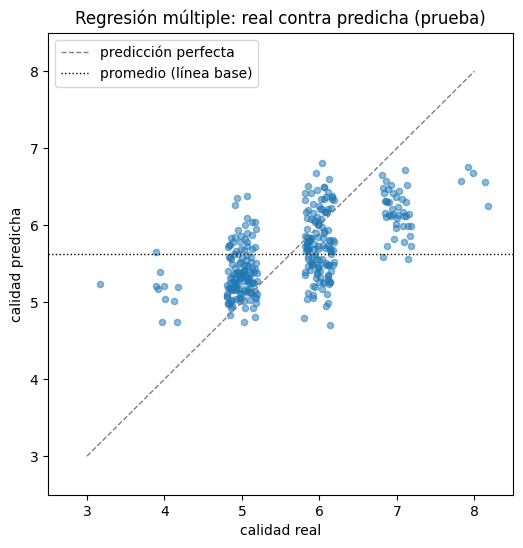

,vinos,predicción promedio
3,1,5.23
4,10,5.14
5,130,5.38
6,132,5.76
7,42,6.18
8,5,6.56


In [9]:
rng = np.random.default_rng(SEMILLA)
x_jitter = y_prueba + rng.uniform(-0.2, 0.2, len(y_prueba))   # solo para ver mejor

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_jitter, pred_multiple, alpha=0.5, s=20)
ax.plot([3, 8], [3, 8], color="gray", linestyle="--", linewidth=1, label="predicción perfecta")
ax.axhline(y_entrena.mean(), color="black", linestyle=":", linewidth=1, label="promedio (línea base)")
ax.set_xlabel("calidad real")
ax.set_ylabel("calidad predicha")
ax.set_title("Regresión múltiple: real contra predicha (prueba)")
ax.set_xlim(2.5, 8.5); ax.set_ylim(2.5, 8.5)
ax.legend()
plt.show()

pd.Series(pred_multiple).groupby(y_prueba.values).agg(["count", "mean"]).round(2) \
    .rename(columns={"count": "vinos", "mean": "predicción promedio"})

Las predicciones aumentan conforme aumenta la calidad real, así que el modelo sí logra ordenar los vinos. Por ejemplo, la predicción promedio pasa de **5.38** para vinos con calidad 5, a **5.76** para los de 6 y **6.18** para los de 7.

### R² a mano

In [10]:
ss_res = np.sum((y_prueba - pred_multiple) ** 2)       # error del modelo
ss_tot = np.sum((y_prueba - y_prueba.mean()) ** 2)     # error de predecir con el promedio
print(f"R² a mano:       {1 - ss_res / ss_tot:.4f}")
print(f"R² scikit-learn: {r2_score(y_prueba, pred_multiple):.4f}")

R² a mano:       0.4032
R² scikit-learn: 0.4032


### Entrenamiento contra prueba

Si el modelo hubiera memorizado, se vería mucho mejor en entrenamiento que en prueba.

In [11]:
pd.DataFrame({
    "entrenamiento": metricas(y_entrena, multiple.predict(X_entrena)),
    "prueba": metricas(y_prueba, pred_multiple),
}).T.round(3)

,MSE,RMSE,MAE,R²
entrenamiento,0.424,0.651,0.500,0.348
prueba,0.390,0.625,0.504,0.403


No vemos señales de **sobreajuste**: el RMSE es incluso un poco menor en prueba (**0.625**) que en entrenamiento (**0.651**), y el R² aumenta de **0.35 a 0.40**.

Los **320 vinos del conjunto de prueba** pudieron resultar un poco más fáciles de predecir. Además, al ser un modelo lineal con 11 variables y 1279 vinos, tiene poco margen para memorizar los datos.



## Clasificación: ¿es bueno o no?

La segunda pregunta es
- ¿cuál?: en lugar de predecir una calificación exacta, queremos saber si un vino puede considerarse bueno (quality ≥ 7) o no.

Para hacerlo, creamos una nueva variable con valores 1 y 0, ajustamos una regresión lineal múltiple y clasificamos como bueno a cualquier vino con una predicción ŷ ≥ 0.5.

Usamos la misma partición de la parte anterior para que los vinos de prueba sean exactamente los mismos y podamos comparar mejor los resultados.

In [15]:
bueno_entrena = (y_entrena >= 7).astype(int)
bueno_prueba = (y_prueba >= 7).astype(int)

print(f"Buenos - entrenamiento: {bueno_entrena.sum()} de {len(bueno_entrena)} ({bueno_entrena.mean():.1%})")
print(f"Buenos - prueba:        {bueno_prueba.sum()} de {len(bueno_prueba)} ({bueno_prueba.mean():.1%})")

Buenos - entrenamiento: 170 de 1279 (13.3%)
Buenos - prueba:        47 de 320 (14.7%)


In [16]:
recta = LinearRegression().fit(X_entrena, bueno_entrena)
y_gorro = recta.predict(X_prueba)
clase = (y_gorro >= 0.5).astype(int)

print(f"Aciertos de la recta:           {(clase == bueno_prueba).mean():.1%}")
print(f"Aciertos de 'siempre no bueno': {(bueno_prueba == 0).mean():.1%}")
print(f"ŷ fuera de [0, 1]: {((y_gorro < 0) | (y_gorro > 1)).sum()} de {len(y_gorro)}")
print(f"ŷ va de {y_gorro.min():.2f} a {y_gorro.max():.2f}")

Aciertos de la recta:           86.2%
Aciertos de 'siempre no bueno': 85.3%
ŷ fuera de [0, 1]: 82 de 320
ŷ va de -0.15 a 0.54


Al observar los resultados, vemos que el modelo acierta el 86.2 % de los vinos de prueba. Sin embargo, predecir siempre “no bueno” ya alcanza un 85.3 %, por lo que la mejora real es de solo 3 vinos de 320.

También observamos que
- 82 predicciones quedaron fuera del rango [0, 1], todas por debajo de cero.
- La predicción más alta fue apenas 0.54, lo que muestra que muy pocos vinos logran superar el umbral de 0.5.

La tercera pregunta:

- ¿A cuáles vinos buenos encuentra?: Al revisar únicamente el porcentaje de aciertos, no podemos distinguir qué tipo de errores está cometiendo el modelo. Por eso, observamos la tabla de clasificación, donde se compara la clase real de cada vino con la clase predicha.

In [17]:
pd.crosstab(bueno_prueba, clase,
            rownames=["real (1 = bueno)"], colnames=["predicho"])

predicho,0,1
real (1 = bueno),,
0,271,2
1,42,5


Al observar la tabla, vemos que de los **47 vinos buenos** del conjunto de prueba, el modelo solo identifica correctamente **5**, mientras que los otros **42** los clasifica como no buenos.

También observamos que el problema no parece ser la falta de datos, ya que había **170 vinos buenos en entrenamiento**. Más bien, se debe a cómo funciona la regresión lineal, busca acercarse en promedio a los valores 0 y 1, pero no está diseñada específicamente para separar clases.

Como la mayoría de los vinos pertenecen a la clase 0, las predicciones tienden a quedarse cerca de cero y pocas veces superan el umbral de **0.5**. El desbalance hace este efecto más evidente, aunque incluso con clases equilibradas la regresión lineal podría seguir generando valores fuera del rango [0, 1].

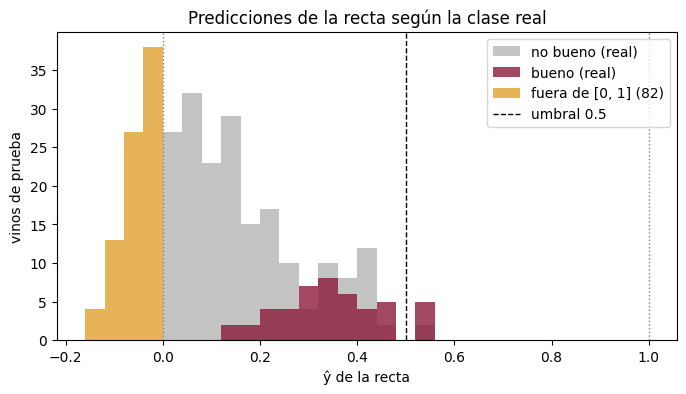

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

ancho = 0.04
bins = np.arange(np.floor(y_gorro.min() / ancho) * ancho, 1 + ancho, ancho).round(2)   # una orilla cae en 0

fuera = (y_gorro < 0) | (y_gorro > 1)

ax.hist(y_gorro[(bueno_prueba == 0) & ~fuera], bins=bins, alpha=0.6, color="#9E9E9E", label="no bueno (real)")
ax.hist(y_gorro[(bueno_prueba == 1) & ~fuera], bins=bins, alpha=0.8, color="#8B1A3A", label="bueno (real)")
ax.hist(y_gorro[fuera], bins=bins, alpha=0.8, color="#E0A030", label=f"fuera de [0, 1] ({fuera.sum()})")

for x in (0, 1):
    ax.axvline(x, color="gray", linestyle=":", linewidth=1)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="umbral 0.5")
ax.set_xlabel("ŷ de la recta")
ax.set_ylabel("vinos de prueba")
ax.set_title("Predicciones de la recta según la clase real")
ax.legend()
plt.show()

Al observar la distribución de las predicciones, vemos que las dos clases se traslapan casi por completo. Aunque los vinos buenos tienden a recibir valores de ŷ un poco más altos, la mayoría sigue quedando por debajo del umbral de **0.5**.

También aparece una cola de predicciones negativas, que no pueden interpretarse como una probabilidad válida. En general, la recta logra ordenar los vinos de cierta forma, pero no consigue separar bien ambas clases usando el umbral de 0.5.

# Conclusión

Al comparar ambos problemas, observamos que la diferencia está en lo que queremos predecir: **un número en un caso y una clase en el otro**. En la regresión, buscamos estimar la calidad del vino y obtuvimos un error aproximado de **0.63 puntos**, reduciendo el error cuadrático un **40 %** frente al modelo base. En cambio, en la clasificación, buscamos identificar si un vino es bueno o no. Aunque el modelo acertó el **86.2 %**, apenas superó el **85.3 %** de predecir siempre "no bueno", una diferencia de solo **3 vinos**. También observamos que **82 de las 320 predicciones fueron negativas**, valores que no pueden interpretarse como la probabilidad de que un vino sea bueno, porque **la recta no tiene límites**, y que el modelo solo identificó **5 de los 47 vinos buenos**. Esto ocurre porque **la regresión lineal busca reducir el error cuadrático y no separar clases**; el desbalance agrava el efecto al acercar las predicciones a cero, pero no es su causa.

En conclusión, el modelo logra estimar y ordenar razonablemente la calidad de los vinos, pero presenta limitaciones importantes al utilizarlo para clasificación con un umbral de **0.5**.


## Declaración de uso de inteligencia artificial

Se utilizó un modelo de inteligencia artificial (Anthropic, Claude Opus 5.5) como asistente para repasar los conceptos de regresión y clasificación, organizar la estructura del notebook con base en el notebook de clase, proponer y depurar el código, proponer borradores de las lecturas de resultados y de la conclusión, y revisar la ortografía y el formato Markdown. Los borradores fueron revisados y reescritos por mi.

Todas las celdas fueron ejecutadas y sus resultados verificados por mi, quien se hace responsable del contenido final.